# ISYE 671: Optimization under Uncertainty — Computational Lab

**Northern Illinois University — Spring 2026**  
**Instructor: Dr. Ziteng Wang**

---

This notebook is the computational companion to the lecture notes on Optimization under Uncertainty. We implement and solve problems from both major paradigms:

**Stochastic Programming** (probability-based):
1. **Two-stage stochastic LP** — Brewery grain purchase with scenario analysis
2. **Value of the Stochastic Solution (VSS)** and **Expected Value of Perfect Information (EVPI)**
3. **Chance-constrained programming** — Warehouse leasing under uncertain donations

**Robust Optimization** (worst-case, no probabilities):
4. **Robust counterpart with budget uncertainty** — Warehouse leasing revisited

**Synthesis:**
5. **Stochastic facility location** — Combining IP with uncertainty
6. **Comparison** — Stochastic vs. robust solutions on the same problem

All models use the **deterministic equivalent** (extensive form) or **robust counterpart** approach, converting problems under uncertainty into standard LP/MIP models solvable with AMPL/Gurobi.

---
## 0. Environment Setup

In [1]:
%pip install amplpy --quiet

from amplpy import AMPL, ampl_notebook

ampl_notebook(
    modules=["gurobi"],
    license_uuid="YOUR-AMPL-LICENSE-UUID"
)

import numpy as np
import matplotlib.pyplot as plt

print("AMPL + Gurobi ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.1 MB/s eta 0:00:00
Licensed to Bundle #7384.7942 expiring 20260531: ISYE 671 linear optimization and network flows, Prof. Ziteng Wang, Northern Illinois University.
AMPL + Gurobi ready.


---
## 1. Two-Stage Stochastic LP: Brewery Grain Purchase

### Problem

Prairie Wind Brewing must purchase grain **now** (before knowing demand) at \$50/unit. Each unit of grain yields 500 barrels of beer, sold at \$25/barrel. If demand exceeds supply, emergency grain can be purchased at \$80/unit. Unsold beer is wasted.

| Scenario | Demand (barrels) | Probability |
|----------|-----------------|-------------|
| Low      | 4,000           | 0.3         |
| Medium   | 6,000           | 0.5         |
| High     | 9,000           | 0.2         |

### Modeling Approach

We write the **extensive form** — a single LP that indexes second-stage variables by scenario.

In [2]:
%%writefile brewery_stochastic.mod
# Two-Stage Stochastic LP: Brewery Grain Purchase
# Extensive form (deterministic equivalent)

set SCENARIOS;
param prob{SCENARIOS} >= 0;       # Scenario probabilities
param demand{SCENARIOS} >= 0;     # Demand realization (barrels)

param grain_cost := 50;           # $/unit for regular grain
param emerg_cost := 80;           # $/unit for emergency grain
param revenue := 25;              # $/barrel sold
param yield_per_unit := 500;      # barrels per unit of grain

# ---- First-stage decision (here-and-now) ----
var grain_purchase >= 0;          # Units of grain purchased now

# ---- Second-stage decisions (per scenario) ----
var production{SCENARIOS} >= 0;   # Barrels produced and sold
var emergency{SCENARIOS} >= 0;    # Units of emergency grain
var waste{SCENARIOS} >= 0;        # Barrels produced but unsold

# Minimize: first-stage cost + expected second-stage cost
minimize total_expected_cost:
    grain_cost * grain_purchase
    + sum{s in SCENARIOS} prob[s] * (
        emerg_cost * emergency[s]
        - revenue * production[s]
    );

# Cannot sell more than demand
subject to demand_limit{s in SCENARIOS}:
    production[s] <= demand[s];

# Production limited by total grain (regular + emergency)
subject to grain_limit{s in SCENARIOS}:
    production[s] + waste[s] = yield_per_unit * (grain_purchase + emergency[s]);

# Non-negativity is handled by variable bounds

Writing brewery_stochastic.mod


In [3]:
%%writefile brewery_stochastic.dat
set SCENARIOS := Low Medium High;

param prob :=
    Low    0.3
    Medium 0.5
    High   0.2;

param demand :=
    Low    4000
    Medium 6000
    High   9000;

Writing brewery_stochastic.dat


In [4]:
# Solve the two-stage stochastic LP
brewery_model = AMPL()
brewery_model.option["solver"] = "gurobi"
brewery_model.read("brewery_stochastic.mod")
brewery_model.readData("brewery_stochastic.dat")
brewery_model.solve()

print(f"Solve status: {brewery_model.solve_result}")
print(f"\n{'='*60}")
print("STOCHASTIC SOLUTION (RP)")
print(f"{'='*60}")

grain_opt = brewery_model.var["grain_purchase"].value()
RP = brewery_model.obj["total_expected_cost"].value()

print(f"\nFirst-stage decision: Purchase {grain_opt:.1f} units of grain")
print(f"  → Produces {grain_opt * 500:.0f} barrels of beer")
print(f"  → Grain cost: ${grain_opt * 50:,.0f}")
print(f"\nOptimal expected total cost: ${RP:,.2f}")

# Scenario-by-scenario breakdown
scenarios = list(brewery_model.set["SCENARIOS"].members())
prod = brewery_model.var["production"]
emerg = brewery_model.var["emergency"]
waste = brewery_model.var["waste"]
prob_p = brewery_model.param["prob"]
demand_p = brewery_model.param["demand"]

print(f"\n{'Scenario':<10} {'Prob':>6} {'Demand':>8} {'Sold':>8} {'Emerg':>8} {'Waste':>8} {'Net Cost':>12}")
print("-" * 70)
for s in scenarios:
    net = 50*grain_opt + 80*emerg[s].value() - 25*prod[s].value()
    print(f"{s:<10} {prob_p[s]:>6.1f} {demand_p[s]:>8.0f} {prod[s].value():>8.0f} "
          f"{emerg[s].value():>8.1f} {waste[s].value():>8.0f} ${net:>11,.2f}")

Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective -149304
2 simplex iterations
Solve status: solved

STOCHASTIC SOLUTION (RP)

First-stage decision: Purchase 12.0 units of grain
  → Produces 6000 barrels of beer
  → Grain cost: $600

Optimal expected total cost: $-149,304.00

Scenario     Prob   Demand     Sold    Emerg    Waste     Net Cost
----------------------------------------------------------------------
Low           0.3     4000     4000      0.0     2000 $ -99,400.00
Medium        0.5     6000     6000      0.0        0 $-149,400.00
High          0.2     9000     9000      6.0        0 $-223,920.00


---
## 1B. Worked Example 2: Agricultural Crop Planning

A farmer has 500 acres and must decide how many acres to plant with wheat, corn, and soybeans **before the growing season**. Yields depend on weather. After harvest:
- The farmer must meet feed requirements: 200 tons of wheat, 240 tons of corn.
- Shortfalls must be purchased at a 40% premium over selling price.
- Excess production is sold at market price.

| Scenario | Wheat yield (t/acre) | Corn yield (t/acre) | Soybean yield (t/acre) | Prob |
|----------|---------------------|--------------------|-----------------------|------|
| Good     | 3.0                 | 3.6                | 4.0                   | 0.3  |
| Average  | 2.5                 | 3.0                | 3.2                   | 0.4  |
| Poor     | 2.0                 | 2.4                | 2.4                   | 0.3  |

The high purchase penalty (40% premium) makes it costly to rely on buying, so the farmer must balance acreage across all crops. This example has **multiple first-stage decisions** and **multiple uncertain parameters**.

In [5]:
%%writefile crop_planning.mod
# Two-Stage Stochastic LP: Agricultural Crop Planning
# First stage: planting decisions (acres per crop)
# Second stage: selling, purchasing to meet feed requirements

set CROPS;
set SCENARIOS;

param prob{SCENARIOS} >= 0;
param total_acres >= 0;

# Costs and prices
param plant_cost{CROPS} >= 0;       # $/acre to plant
param sell_price{CROPS} >= 0;        # $/ton selling price
param buy_price{CROPS} >= 0;         # $/ton purchase price (for shortfall)

# Requirements and yields
param min_feed{CROPS} >= 0;          # Minimum tons needed for feed
param yield_rate{CROPS, SCENARIOS} >= 0;  # Tons per acre by scenario

# ---- First stage: planting decisions ----
var plant{CROPS} >= 0;               # Acres planted per crop

# ---- Second stage: sales, purchases (per scenario) ----
var sell{CROPS, SCENARIOS} >= 0;      # Tons sold
var buy{CROPS, SCENARIOS} >= 0;       # Tons purchased (shortfall)

# Objective: minimize planting cost + expected (purchase cost - sales revenue)
minimize total_expected_cost:
    sum{c in CROPS} plant_cost[c] * plant[c]
    + sum{s in SCENARIOS} prob[s] * (
        sum{c in CROPS} buy_price[c] * buy[c,s]
        - sum{c in CROPS} sell_price[c] * sell[c,s]
    );

# Total acres constraint
subject to acreage:
    sum{c in CROPS} plant[c] <= total_acres;

# Feed requirement: production + purchases - sales >= minimum
subject to feed_req{c in CROPS, s in SCENARIOS}:
    yield_rate[c,s] * plant[c] + buy[c,s] - sell[c,s] >= min_feed[c];

# Can only sell what you produce beyond feed requirements
# (already handled by the feed_req constraint — sales reduce available supply)

Writing crop_planning.mod


In [6]:
%%writefile crop_planning.dat
set CROPS := Wheat Corn Soybeans;
set SCENARIOS := Good Average Poor;

param prob :=
    Good 0.3  Average 0.4  Poor 0.3;

param total_acres := 500;

param plant_cost :=
    Wheat 150  Corn 230  Soybeans 260;

# Selling prices ($/ton)
param sell_price :=
    Wheat 170  Corn 150  Soybeans 36;

# Purchase price = higher premium for shortfall (40% over sell price)
# This makes it expensive to skip planting and just buy
param buy_price :=
    Wheat 238  Corn 210  Soybeans 50;

# Feed requirements: now soybeans also have a feed requirement
param min_feed :=
    Wheat 200  Corn 240  Soybeans 0;

# Yields (tons per acre) — reduced soybean yields significantly
param yield_rate:
              Good  Average  Poor :=
Wheat          3.0    2.5     2.0
Corn           3.6    3.0     2.4
Soybeans       4.0    3.2     2.4;


Writing crop_planning.dat


In [7]:
# Solve the crop planning stochastic LP
crop_model = AMPL()
crop_model.option["solver"] = "gurobi"
crop_model.option["gurobi_options"] = "outlev=0"
crop_model.read("crop_planning.mod")
crop_model.readData("crop_planning.dat")
crop_model.solve()

print(f"Solve status: {crop_model.solve_result}")
print(f"Total expected cost: ${crop_model.obj['total_expected_cost'].value():,.2f}")

# Display planting decisions
crops = list(crop_model.set['CROPS'].members())
plant_var = crop_model.var['plant']
print(f"\n{'='*50}")
print("FIRST-STAGE DECISIONS: Planting Plan")
print(f"{'='*50}")
print(f"{'Crop':<12} {'Acres':>8}")
print('-' * 22)
total_planted = 0
for c in crops:
    acres = plant_var[c].value()
    total_planted += acres
    print(f"{c:<12} {acres:>8.1f}")
print(f"{'Total':<12} {total_planted:>8.1f} / 500")

# Display scenario-by-scenario outcomes
scenarios = list(crop_model.set['SCENARIOS'].members())
sell_var = crop_model.var['sell']
buy_var = crop_model.var['buy']
yield_p = crop_model.param['yield_rate']
prob_p = crop_model.param['prob']
sp = crop_model.param['sell_price']
bp = crop_model.param['buy_price']
pc = crop_model.param['plant_cost']

print(f"\n{'='*70}")
print("SECOND-STAGE OUTCOMES BY SCENARIO")
print(f"{'='*70}")
for s in scenarios:
    print(f"\n--- Scenario: {s} (prob = {prob_p[s]}) ---")
    print(f"{'Crop':<12} {'Harvest':>8} {'Feed':>8} {'Sell':>8} {'Buy':>8}")
    print('-' * 48)
    scenario_rev = 0
    scenario_cost = 0
    for c in crops:
        harvest = yield_p[c, s] * plant_var[c].value()
        sold = sell_var[c, s].value()
        bought = buy_var[c, s].value()
        feed = crop_model.param['min_feed'][c]
        scenario_rev += sp[c] * sold
        scenario_cost += bp[c] * bought
        print(f"{c:<12} {harvest:>8.0f} {feed:>8.0f} {sold:>8.0f} {bought:>8.0f}")
    plant_cost_total = sum(pc[c] * plant_var[c].value() for c in crops)
    net = plant_cost_total + scenario_cost - scenario_rev
    print(f"  Net cost in this scenario: ${net:,.0f}")

Gurobi 13.0.0:   tech:outlev = 0
Gurobi 13.0.0: optimal solution; objective -62236
11 simplex iterations
Solve status: solved
Total expected cost: $-62,236.00

FIRST-STAGE DECISIONS: Planting Plan
Crop            Acres
----------------------
Wheat           420.0
Corn             80.0
Soybeans          0.0
Total           500.0 / 500

SECOND-STAGE OUTCOMES BY SCENARIO

--- Scenario: Good (prob = 0.3) ---
Crop          Harvest     Feed     Sell      Buy
------------------------------------------------
Wheat            1260      200     1060        0
Corn              288      240       48        0
Soybeans            0        0        0        0
  Net cost in this scenario: $-106,000

--- Scenario: Average (prob = 0.4) ---
Crop          Harvest     Feed     Sell      Buy
------------------------------------------------
Wheat            1050      200      850        0
Corn              240      240        0        0
Soybeans            0        0        0        0
  Net cost in this scen

---
## 1C. Worked Example 3: Emergency Supply Pre-Positioning

A disaster relief agency must pre-position supply kits at 3 warehouses **before hurricane season**. After a hurricane, kits are shipped to affected zones. This example has:
- **Multiple first-stage decisions** across locations (spatial pre-positioning)
- **Transportation structure** in the second stage (warehouse → zone shipping)
- **Penalty for unmet demand** (\$500/kit) and **salvage value** for unused kits (\$50/kit)
- A **no-hurricane scenario** showing that pre-positioned kits aren't wasted

| Scenario | Zone A | Zone B | Zone C | Probability |
|----------|--------|--------|--------|-------------|
| Cat-1    | 100    | 80     | 50     | 0.40        |
| Cat-3    | 300    | 200    | 150    | 0.35        |
| Cat-5    | 500    | 400    | 350    | 0.15        |
| None     | 0      | 0      | 0      | 0.10        |

In [9]:
%%writefile emergency_supply.mod
# Two-Stage Stochastic LP: Emergency Supply Pre-Positioning
# First stage: pre-position kits at warehouses
# Second stage: ship to zones, record shortfall and salvage

set WAREHOUSES;
set ZONES;
set SCENARIOS;

param prob{SCENARIOS} >= 0;
param preposition_cost := 200;     # $/kit to pre-position
param penalty := 500;               # $/kit unmet demand
param salvage := 50;                # $/kit unused (salvage value)
param warehouse_cap{WAREHOUSES} >= 0;
param ship_cost{WAREHOUSES, ZONES} >= 0;
param demand{ZONES, SCENARIOS} >= 0;

# ---- First stage ----
var prepos{WAREHOUSES} >= 0;         # Kits pre-positioned

# ---- Second stage ----
var ship{WAREHOUSES, ZONES, SCENARIOS} >= 0;   # Kits shipped
var shortfall{ZONES, SCENARIOS} >= 0;           # Unmet demand
var unused{WAREHOUSES, SCENARIOS} >= 0;         # Salvaged kits

minimize total_expected_cost:
    sum{w in WAREHOUSES} preposition_cost * prepos[w]
    + sum{s in SCENARIOS} prob[s] * (
        sum{w in WAREHOUSES, z in ZONES} ship_cost[w,z] * ship[w,z,s]
        + penalty * sum{z in ZONES} shortfall[z,s]
        - salvage * sum{w in WAREHOUSES} unused[w,s]
    );

# Warehouse capacity
subject to cap{w in WAREHOUSES}:
    prepos[w] <= warehouse_cap[w];

# Conservation at warehouse: ship out + salvage = pre-positioned
subject to warehouse_balance{w in WAREHOUSES, s in SCENARIOS}:
    sum{z in ZONES} ship[w,z,s] + unused[w,s] = prepos[w];

# Demand satisfaction: shipped in + shortfall = demand
subject to zone_demand{z in ZONES, s in SCENARIOS}:
    sum{w in WAREHOUSES} ship[w,z,s] + shortfall[z,s] = demand[z,s];

Overwriting emergency_supply.mod


In [10]:
%%writefile emergency_supply.dat
set WAREHOUSES := W1 W2 W3;
set ZONES := ZoneA ZoneB ZoneC;
set SCENARIOS := Cat1 Cat3 Cat5 None;

param prob :=
    Cat1 0.40  Cat3 0.35  Cat5 0.15  None 0.10;

param warehouse_cap :=
    W1 500  W2 500  W3 500;

param ship_cost:
        ZoneA  ZoneB  ZoneC :=
W1        20     40     60
W2        50     15     35
W3        45     30     10;

param demand:
          Cat1  Cat3  Cat5  None :=
ZoneA      100   300   500    0
ZoneB       80   200   400    0
ZoneC       50   150   350    0;

Writing emergency_supply.dat


In [11]:
# Solve emergency supply pre-positioning
emerg_model = AMPL()
emerg_model.option["solver"] = "gurobi"
emerg_model.option["gurobi_options"] = "outlev=0"
emerg_model.read("emergency_supply.mod")
emerg_model.readData("emergency_supply.dat")
emerg_model.solve()

print(f"Solve status: {emerg_model.solve_result}")
print(f"Total expected cost: ${emerg_model.obj['total_expected_cost'].value():,.2f}")

# Pre-positioning decisions
warehouses = list(emerg_model.set['WAREHOUSES'].members())
zones = list(emerg_model.set['ZONES'].members())
scenarios_e = list(emerg_model.set['SCENARIOS'].members())
prepos_var = emerg_model.var['prepos']

print(f"\n{'='*55}")
print("FIRST-STAGE DECISIONS: Pre-Positioning Plan")
print(f"{'='*55}")
total_kits = 0
for w in warehouses:
    kits = prepos_var[w].value()
    total_kits += kits
    print(f"  {w}: {kits:>6.0f} kits (cost: ${kits * 200:>10,.0f})")
print(f"  Total: {total_kits:.0f} kits, pre-positioning cost: ${total_kits * 200:,.0f}")

# Scenario outcomes
ship_var = emerg_model.var['ship']
short_var = emerg_model.var['shortfall']
unused_var = emerg_model.var['unused']
demand_e = emerg_model.param['demand']
prob_e = emerg_model.param['prob']
sc = emerg_model.param['ship_cost']

print(f"\n{'='*55}")
print("SECOND-STAGE OUTCOMES BY SCENARIO")
print(f"{'='*55}")
for s in scenarios_e:
    total_demand = sum(demand_e[z, s] for z in zones)
    total_short = sum(short_var[z, s].value() for z in zones)
    total_salvage = sum(unused_var[w, s].value() for w in warehouses)
    ship_cost_s = sum(sc[w,z] * ship_var[w,z,s].value()
                     for w in warehouses for z in zones)

    print(f"\n--- {s} (prob={prob_e[s]:.2f}, total demand={total_demand:.0f}) ---")

    # Shipping table
    print(f"  {'':>4}", end="")
    for z in zones:
        print(f" {z:>7}", end="")
    print(f" {'Unused':>8}")
    for w in warehouses:
        print(f"  {w:>4}", end="")
        for z in zones:
            val = ship_var[w, z, s].value()
            print(f" {val:>7.0f}", end="")
        print(f" {unused_var[w, s].value():>8.0f}")

    print(f"  Shortfall: {total_short:.0f} kits")
    print(f"  Shipping cost: ${ship_cost_s:,.0f} | "
          f"Penalty: ${total_short * 500:,.0f} | "
          f"Salvage: ${total_salvage * 50:,.0f}")

Gurobi 13.0.0:   tech:outlev = 0
Gurobi 13.0.0: optimal solution; objective 170080
21 simplex iterations
Solve status: solved
Total expected cost: $170,080.00

FIRST-STAGE DECISIONS: Pre-Positioning Plan
  W1:    300 kits (cost: $    60,000)
  W2:    200 kits (cost: $    40,000)
  W3:    150 kits (cost: $    30,000)
  Total: 650 kits, pre-positioning cost: $130,000

SECOND-STAGE OUTCOMES BY SCENARIO

--- Cat1 (prob=0.40, total demand=230) ---
         ZoneA   ZoneB   ZoneC   Unused
    W1     100       0       0      200
    W2       0      80       0      120
    W3       0       0      50      100
  Shortfall: 0 kits
  Shipping cost: $3,700 | Penalty: $0 | Salvage: $21,000

--- Cat3 (prob=0.35, total demand=650) ---
         ZoneA   ZoneB   ZoneC   Unused
    W1     300       0       0        0
    W2       0     200       0        0
    W3       0       0     150        0
  Shortfall: 0 kits
  Shipping cost: $10,500 | Penalty: $0 | Salvage: $0

--- Cat5 (prob=0.15, total demand=1250

In [12]:
# Compare stochastic solution to expected-value approach
# Expected demand by zone
exp_demand = {z: sum(prob_e[s] * demand_e[z, s] for s in scenarios_e) for z in zones}
print("Expected demand by zone:")
for z in zones:
    print(f"  {z}: {exp_demand[z]:.0f} kits")
print(f"  Total expected: {sum(exp_demand.values()):.0f} kits")
print(f"  Stochastic solution pre-positions: {total_kits:.0f} kits")
print(f"\n💡 The stochastic model pre-positions MORE kits than expected demand")
print(f"   because it hedges against the severe hurricane scenario.")
print(f"   We will quantify this benefit (VSS) in the next section.")


Expected demand by zone:
  ZoneA: 220 kits
  ZoneB: 162 kits
  ZoneC: 125 kits
  Total expected: 507 kits
  Stochastic solution pre-positions: 650 kits

💡 The stochastic model pre-positions MORE kits than expected demand
   because it hedges against the severe hurricane scenario.
   We will quantify this benefit (VSS) in the next section.


---
## Summary: Patterns Across Examples

| Example | First-Stage | Second-Stage | Uncertain Parameters | Size |
|---------|-------------|-------------|---------------------|------|
| Brewery | 1 variable (grain) | 3 vars × 3 scenarios | Demand | 10 vars, 6 cons |
| Crop planning | 3 variables (acres) | 6 vars × 3 scenarios | Yields | 21 vars, 10 cons |
| Emergency supply | 3 variables (kits) | 15 vars × 4 scenarios | Zone demands | 63 vars, 27 cons |

The formulation recipe is always the same:
1. Identify timing (what's decided before/after uncertainty)
2. Write the deterministic version
3. Replicate second-stage constraints for each scenario
4. Weight second-stage costs by probability

---
## 2. Computing VSS and EVPI: Emergency Supply Example

We quantify the value of modeling uncertainty using the emergency supply pre-positioning problem. The three key quantities are:

- **WS** (Wait-and-See): expected cost if we had a perfect forecast
- **RP** (Recourse Problem): optimal expected cost from the stochastic model
- **EEV** (Expected result of EV): cost when we ignore uncertainty

### 2.1 Step 1: Expected Value (EV) Solution

Replace uncertain demands with their expected values and solve.

In [ ]:
# Step 1: Solve with expected demand (single scenario at the mean)
exp_demand = {z: sum(prob_e[s] * demand_e[z, s] for s in scenarios_e) for z in zones}
print("Expected demand by zone:")
for z in zones:
    print(f"  {z}: {exp_demand[z]:.0f} kits")
print(f"  Total: {sum(exp_demand.values()):.0f} kits")

# Solve with expected demand only (load data programmatically)
ev_model = AMPL()
ev_model.option["solver"] = "gurobi"
ev_model.option["gurobi_options"] = "outlev=0"
ev_model.read("emergency_supply.mod")

ev_model.set["WAREHOUSES"] = warehouses
ev_model.set["ZONES"] = zones
ev_model.set["SCENARIOS"] = ["Expected"]
ev_model.param["prob"] = {"Expected": 1.0}
ev_model.param["warehouse_cap"] = {w: 500 for w in warehouses}
for w in warehouses:
    for z in zones:
        ev_model.param["ship_cost"][w, z] = sc[w, z]
for z in zones:
    ev_model.param["demand"][z, "Expected"] = exp_demand[z]
ev_model.solve()

ev_prepos = {w: ev_model.var['prepos'][w].value() for w in warehouses}
print(f"\nEV solution (ignoring uncertainty):")
for w in warehouses:
    print(f"  {w}: {ev_prepos[w]:>6.0f} kits")
print(f"  Total: {sum(ev_prepos.values()):.0f} kits")

# Compare to stochastic solution
print(f"\nStochastic solution:")
for w in warehouses:
    print(f"  {w}: {prepos_var[w].value():>6.0f} kits")
print(f"  Total: {sum(prepos_var[w].value() for w in warehouses):.0f} kits")


Expected demand by zone:
  ZoneA: 220 kits
  ZoneB: 162 kits
  ZoneC: 125 kits
  Total: 507 kits
Gurobi 13.0.0:   tech:outlev = 0
Gurobi 13.0.0: optimal solution; objective 109480
6 simplex iterations

EV solution (ignoring uncertainty):
  W1:    220 kits
  W2:    162 kits
  W3:    125 kits
  Total: 507 kits

Stochastic solution:
  W1:    300 kits
  W2:    200 kits
  W3:    150 kits
  Total: 650 kits


In [ ]:
# Step 2: Evaluate the EV decision across ALL scenarios (compute EEV)
# Fix first-stage to the EV solution, then let second-stage optimize per scenario
eev_model = AMPL()
eev_model.option["solver"] = "gurobi"
eev_model.option["gurobi_options"] = "outlev=0"
eev_model.read("emergency_supply.mod")
eev_model.readData("emergency_supply.dat")
for w in warehouses:
    eev_model.var['prepos'][w].fix(ev_prepos[w])
eev_model.solve()

EEV = eev_model.obj['total_expected_cost'].value()
print(f"EEV (expected cost of ignoring uncertainty): ${EEV:,.2f}")

# Show what goes wrong in each scenario
print(f"\nScenario-by-scenario impact of the EV decision:")
short_eev = eev_model.var['shortfall']
print(f"{'Scenario':<8} {'Total Demand':>12} {'Shortfall':>10}")
print("-" * 35)
for s in scenarios_e:
    total_d = sum(demand_e[z, s] for z in zones)
    total_s = sum(short_eev[z, s].value() for z in zones)
    flag = " ← under-prepared!" if total_s > 0.5 else ""
    print(f"{s:<8} {total_d:>12.0f} {total_s:>10.0f}{flag}")


Gurobi 13.0.0:   tech:outlev = 0
Gurobi 13.0.0: optimal solution; objective 179595
23 simplex iterations
EEV (expected cost of ignoring uncertainty): $179,595.00

Scenario-by-scenario impact of the EV decision:
Scenario Total Demand  Shortfall
-----------------------------------
Cat1              230          0
Cat3              650        143 ← under-prepared!
Cat5             1250        743 ← under-prepared!
None                0          0


In [ ]:
# Step 3: Wait-and-See (WS) — solve each scenario independently
# With perfect information, we would optimize for each scenario separately
WS = 0
print("Wait-and-See solutions (perfect information):")
print(f"{'Scenario':<8} {'Prob':>6} {'Optimal Cost':>14} {'Pre-positioned':>15}")
print("-" * 50)

for s in scenarios_e:
    ws_model = AMPL()
    ws_model.option["solver"] = "gurobi"
    ws_model.option["gurobi_options"] = "outlev=0"
    ws_model.read("emergency_supply.mod")

    # Load single-scenario data programmatically
    ws_model.set["WAREHOUSES"] = warehouses
    ws_model.set["ZONES"] = zones
    ws_model.set["SCENARIOS"] = [s]
    ws_model.param["prob"] = {s: 1.0}
    ws_model.param["warehouse_cap"] = {w: 500 for w in warehouses}
    for w in warehouses:
        for z in zones:
            ws_model.param["ship_cost"][w, z] = sc[w, z]
    for z in zones:
        ws_model.param["demand"][z, s] = demand_e[z, s]
    ws_model.solve()

    z_s = ws_model.obj['total_expected_cost'].value()
    total_prepos = sum(ws_model.var['prepos'][w].value() for w in warehouses)
    weighted = prob_e[s] * z_s
    WS += weighted
    print(f"{s:<8} {prob_e[s]:>6.2f} ${z_s:>13,.2f} {total_prepos:>15.0f}")

print(f"\nWS (expected cost with perfect info): ${WS:,.2f}")


Wait-and-See solutions (perfect information):
Scenario   Prob   Optimal Cost  Pre-positioned
--------------------------------------------------
Gurobi 13.0.0:   tech:outlev = 0
Gurobi 13.0.0: optimal solution; objective 49700
5 simplex iterations
Cat1       0.40 $    49,700.00             230
Gurobi 13.0.0:   tech:outlev = 0
Gurobi 13.0.0: optimal solution; objective 140500
6 simplex iterations
Cat3       0.35 $   140,500.00             650
Gurobi 13.0.0:   tech:outlev = 0
Gurobi 13.0.0: optimal solution; objective 269500
5 simplex iterations
Cat5       0.15 $   269,500.00            1250
Gurobi 13.0.0:   tech:outlev = 0
Gurobi 13.0.0: optimal solution; objective 0
0 simplex iterations
None       0.10 $         0.00               0

WS (expected cost with perfect info): $109,480.00


In [ ]:
# Step 4: Compute VSS and EVPI
RP = emerg_model.obj['total_expected_cost'].value()
VSS = EEV - RP
EVPI = RP - WS

print("=" * 60)
print("SUMMARY: Value of Information — Emergency Supply")
print("=" * 60)
print(f"\n  WS  (Wait-and-See / perfect info):  ${WS:>12,.2f}")
print(f"  RP  (Stochastic solution):          ${RP:>12,.2f}")
print(f"  EEV (Ignoring uncertainty):          ${EEV:>12,.2f}")
print(f"\n  EVPI = RP - WS = ${EVPI:>12,.2f}")
print(f"    → Maximum we should pay for a perfect hurricane forecast")
print(f"\n  VSS  = EEV - RP = ${VSS:>12,.2f}")
print(f"    → Savings from using the stochastic model vs. ignoring uncertainty")
print(f"\n  Verification: WS ≤ RP ≤ EEV")
print(f"                ${WS:,.2f} ≤ ${RP:,.2f} ≤ ${EEV:,.2f}  ", end="")
print("✓" if WS <= RP + 0.01 and RP <= EEV + 0.01 else "✗")

if VSS > 100:
    print(f"\n💡 The VSS is substantial (${VSS:,.0f}). Ignoring uncertainty leads")
    print(f"   to under-preparation for severe hurricanes, incurring large penalties.")
    print(f"   The stochastic model hedges by pre-positioning extra kits.")


SUMMARY: Value of Information — Emergency Supply

  WS  (Wait-and-See / perfect info):  $  109,480.00
  RP  (Stochastic solution):          $  170,080.00
  EEV (Ignoring uncertainty):          $  179,595.00

  EVPI = RP - WS = $   60,600.00
    → Maximum we should pay for a perfect hurricane forecast

  VSS  = EEV - RP = $    9,515.00
    → Savings from using the stochastic model vs. ignoring uncertainty

  Verification: WS ≤ RP ≤ EEV
                $109,480.00 ≤ $170,080.00 ≤ $179,595.00  ✓

💡 The VSS is substantial ($9,515). Ignoring uncertainty leads
   to under-preparation for severe hurricanes, incurring large penalties.
   The stochastic model hedges by pre-positioning extra kits.


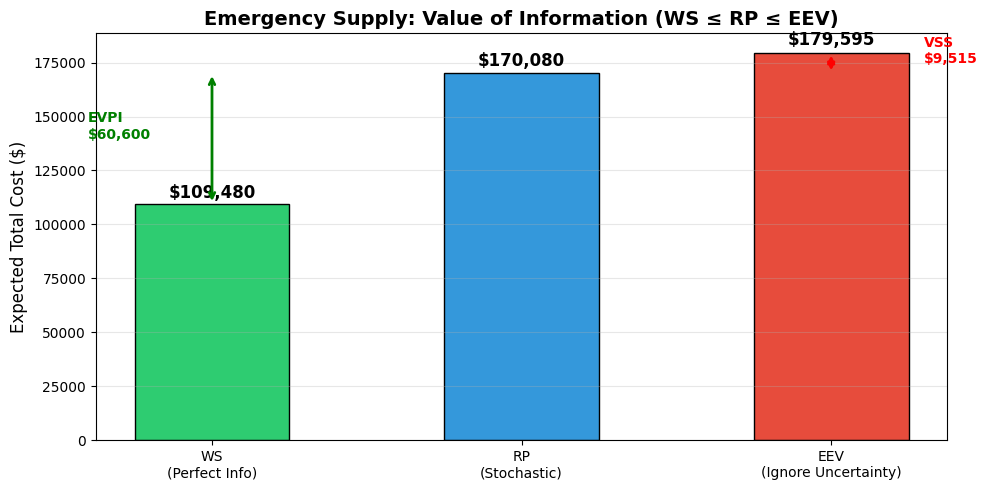

In [ ]:
# Visualize the three bounds
fig, ax = plt.subplots(figsize=(10, 5))

labels = ['WS\n(Perfect Info)', 'RP\n(Stochastic)', 'EEV\n(Ignore Uncertainty)']
values = [WS, RP, EEV]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='black')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(val)*0.01,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Annotate EVPI and VSS
mid_evpi = (WS + RP) / 2
mid_vss = (RP + EEV) / 2

ax.annotate('', xy=(0, RP), xytext=(0, WS),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax.text(-0.4, mid_evpi, f'EVPI\n${EVPI:,.0f}', fontsize=10, color='green', fontweight='bold')

ax.annotate('', xy=(2, EEV), xytext=(2, RP),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(2.3, mid_vss, f'VSS\n${VSS:,.0f}', fontsize=10, color='red', fontweight='bold')

ax.set_ylabel('Expected Total Cost ($)', fontsize=12)
ax.set_title('Emergency Supply: Value of Information (WS ≤ RP ≤ EEV)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## 3. Chance-Constrained Programming

### Problem: Food Bank Warehouse Leasing

A food bank must decide how much warehouse space (in sq ft) to lease. Monthly donation volumes are uncertain — we have 10 historical scenarios. The food bank wants to ensure donations can be stored without overflow in at least **90% of scenarios**.

This is a **chance constraint**: $\Pr(\text{space} \geq \text{donations}) \geq 0.90$

In [ ]:
%%writefile chance_warehouse.mod
# Chance-Constrained Warehouse Leasing
# Ensure feasibility in at least (1 - epsilon) fraction of scenarios

set SCENARIOS;
param prob{SCENARIOS} >= 0;
param donations{SCENARIOS} >= 0;    # Donation volume in each scenario (sq ft)
param epsilon;                       # Allowed violation probability
param lease_cost := 5;               # $/sq ft per month
param M := 100000;                   # Big-M

# Decision: warehouse space to lease
var space >= 0;

# Binary: does scenario s violate the storage constraint?
var violate{SCENARIOS} binary;

# Minimize lease cost
minimize monthly_cost:
    lease_cost * space;

# Storage constraint: donations[s] <= space, OR violation allowed
subject to storage{s in SCENARIOS}:
    donations[s] <= space + M * violate[s];

# Chance constraint: total probability of violation <= epsilon
subject to reliability:
    sum{s in SCENARIOS} prob[s] * violate[s] <= epsilon;

Writing chance_warehouse.mod


In [ ]:
%%writefile chance_warehouse.dat
# 10 equally likely historical donation scenarios

set SCENARIOS := S1 S2 S3 S4 S5 S6 S7 S8 S9 S10;

param prob :=
    S1 0.1  S2 0.1  S3 0.1  S4 0.1  S5 0.1
    S6 0.1  S7 0.1  S8 0.1  S9 0.1  S10 0.1;

param donations :=
    S1  3200
    S2  4100
    S3  3800
    S4  5200
    S5  4500
    S6  3600
    S7  6100
    S8  4800
    S9  5500
    S10 4000;

param epsilon := 0.10;  # Allow 10% violation → 90% reliability

Writing chance_warehouse.dat


In [ ]:
# Solve chance-constrained model at 90% reliability
cc_model = AMPL()
cc_model.option["solver"] = "gurobi"
cc_model.read("chance_warehouse.mod")
cc_model.readData("chance_warehouse.dat")
cc_model.solve()

space_90 = cc_model.var["space"].value()
cost_90 = cc_model.obj["monthly_cost"].value()

print(f"=== 90% Reliability (epsilon = 0.10) ===")
print(f"Warehouse space: {space_90:,.0f} sq ft")
print(f"Monthly cost:    ${cost_90:,.0f}")

# Show which scenarios are violated
violate_var = cc_model.var["violate"]
donations_p = cc_model.param["donations"]
scenarios_cc = list(cc_model.set["SCENARIOS"].members())

print(f"\n{'Scenario':<10} {'Donations':>10} {'Violated?':>10}")
print("-" * 35)
for s in scenarios_cc:
    v = "YES" if violate_var[s].value() > 0.5 else "no"
    print(f"{s:<10} {donations_p[s]:>10,.0f} {v:>10}")

Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 27500
0 simplex iterations
=== 90% Reliability (epsilon = 0.10) ===
Warehouse space: 5,500 sq ft
Monthly cost:    $27,500

Scenario    Donations  Violated?
-----------------------------------
S1              3,200         no
S2              4,100         no
S3              3,800         no
S4              5,200         no
S5              4,500         no
S6              3,600         no
S7              6,100        YES
S8              4,800         no
S9              5,500         no
S10             4,000         no


In [ ]:
# Compare different reliability levels
reliability_levels = [0.70, 0.80, 0.90, 0.95, 1.00]
results = []

for rel in reliability_levels:
    eps = 1 - rel
    m = AMPL()
    m.option["solver"] = "gurobi"
    m.read("chance_warehouse.mod")
    m.readData("chance_warehouse.dat")
    m.param["epsilon"] = eps
    m.solve()
    space_val = m.var["space"].value()
    cost_val = m.obj["monthly_cost"].value()
    results.append((rel, space_val, cost_val))

print(f"{'Reliability':>12} {'Space (sq ft)':>14} {'Monthly Cost':>14}")
print("-" * 45)
for rel, sp, co in results:
    print(f"{rel:>11.0%} {sp:>14,.0f} ${co:>13,.0f}")

print("\n💡 Higher reliability → more space → higher cost.")
print("   The 100% case must cover the worst-case scenario (S7: 6,100 sq ft).")

Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 24000
9 simplex iterations
1 branching node
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 26000
12 simplex iterations
1 branching node
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 27500
0 simplex iterations
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 30500
0 simplex iterations
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 30500
0 simplex iterations
 Reliability  Space (sq ft)   Monthly Cost
---------------------------------------------
        70%          4,800 $       24,000
        80%          5,200 $       26,000
        90%          5,500 $       27,500
        95%          6,100 $       30,500
       100%          6,100 $       30,500

💡 Higher reliability → more space → higher cost.
   The 100% case must cover the worst-case scenario (S7: 6,100 sq ft).


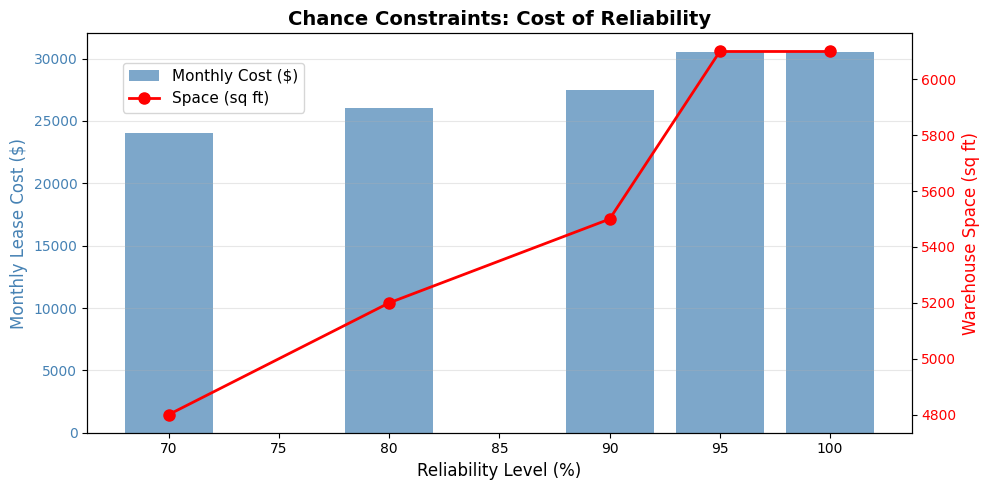

In [ ]:
# Visualize reliability vs. cost trade-off
fig, ax1 = plt.subplots(figsize=(10, 5))

rels = [r[0]*100 for r in results]
spaces = [r[1] for r in results]
costs = [r[2] for r in results]

ax1.bar(rels, costs, width=4, color='steelblue', alpha=0.7, label='Monthly Cost ($)')
ax1.set_xlabel('Reliability Level (%)', fontsize=12)
ax1.set_ylabel('Monthly Lease Cost ($)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(rels, spaces, 'ro-', linewidth=2, markersize=8, label='Space (sq ft)')
ax2.set_ylabel('Warehouse Space (sq ft)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title('Chance Constraints: Cost of Reliability', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88), fontsize=11)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Robust Optimization

### Problem: Warehouse Leasing with Budget Uncertainty

Instead of discrete scenarios, suppose we only know that the nominal monthly donation volume is 4,500 sq ft with each component (from 5 donation sources) uncertain within ±20%. We use **budget uncertainty** (Bertsimas–Sim) to control conservatism.

In [ ]:
%%writefile robust_warehouse.mod
# Robust Warehouse Leasing — Budget Uncertainty (Bertsimas-Sim)
# Donations come from 5 sources, each with +/- 20% uncertainty

set SOURCES;
param nominal{SOURCES} >= 0;       # Nominal donation from each source
param deviation{SOURCES} >= 0;     # Maximum deviation (= 20% of nominal)
param Gamma >= 0;                  # Budget of uncertainty (0 = nominal, 5 = box)
param lease_cost := 5;             # $/sq ft per month

# Decision: warehouse space to lease
var space >= 0;

# Dual variables for the inner maximization (budget robust counterpart)
var lambda >= 0;                   # Dual for budget constraint
var mu{SOURCES} >= 0;              # Dual for absolute value constraints

# Minimize lease cost
minimize monthly_cost:
    lease_cost * space;

# Robust constraint: space >= worst-case total donations
# The worst-case total = sum(nominal) + max over uncertainty set of sum(deviation * zeta)
# Using LP duality of the inner max, the robust counterpart is:
subject to robust_capacity:
    space >= sum{s in SOURCES} nominal[s]
            + Gamma * lambda
            + sum{s in SOURCES} mu[s];

subject to dual_bound{s in SOURCES}:
    lambda + mu[s] >= deviation[s];

Writing robust_warehouse.mod


In [ ]:
%%writefile robust_warehouse.dat
# 5 donation sources with nominal volumes and 20% deviation

set SOURCES := Retail Wholesale Corporate Individual Events;

param nominal :=
    Retail      1200
    Wholesale    900
    Corporate   1000
    Individual   800
    Events       600;

param deviation :=
    Retail       240
    Wholesale    180
    Corporate    200
    Individual   160
    Events       120;

# Gamma will be varied programmatically
param Gamma := 3;

Writing robust_warehouse.dat


In [ ]:
# Solve for different levels of conservatism (Gamma)
gamma_values = [0, 1, 2, 3, 4, 5]
robust_results = []

print(f"{'Gamma':>6} {'Interpretation':<30} {'Space':>10} {'Cost':>10}")
print("-" * 60)

interp = {
    0: "Nominal (no uncertainty)",
    1: "At most 1 source deviates",
    2: "At most 2 sources deviate",
    3: "At most 3 sources deviate",
    4: "At most 4 sources deviate",
    5: "All sources deviate (box)"
}

for g in gamma_values:
    m = AMPL()
    m.option["solver"] = "gurobi"
    m.read("robust_warehouse.mod")
    m.readData("robust_warehouse.dat")
    m.param["Gamma"] = g
    m.solve()
    sp = m.var["space"].value()
    co = m.obj["monthly_cost"].value()
    robust_results.append((g, sp, co))
    print(f"{g:>6} {interp[g]:<30} {sp:>10,.0f} ${co:>9,.0f}")

print("\n💡 Gamma controls conservatism: 0 = optimistic, 5 = worst-case.")
print("   Budget uncertainty avoids over-conservatism of box uncertainty.")

 Gamma Interpretation                      Space       Cost
------------------------------------------------------------
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 22500
0 simplex iterations
     0 Nominal (no uncertainty)            4,500 $   22,500
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 23700
2 simplex iterations
     1 At most 1 source deviates           4,740 $   23,700
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 24700
3 simplex iterations
     2 At most 2 sources deviate           4,940 $   24,700
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 25600
4 simplex iterations
     3 At most 3 sources deviate           5,120 $   25,600
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 26400
5 simplex iterations
     4 At most 4 sources deviate           5,280 $   26,400
Gurobi 13.0.0: Gurobi 13.0.0: optimal solution; objective 27000


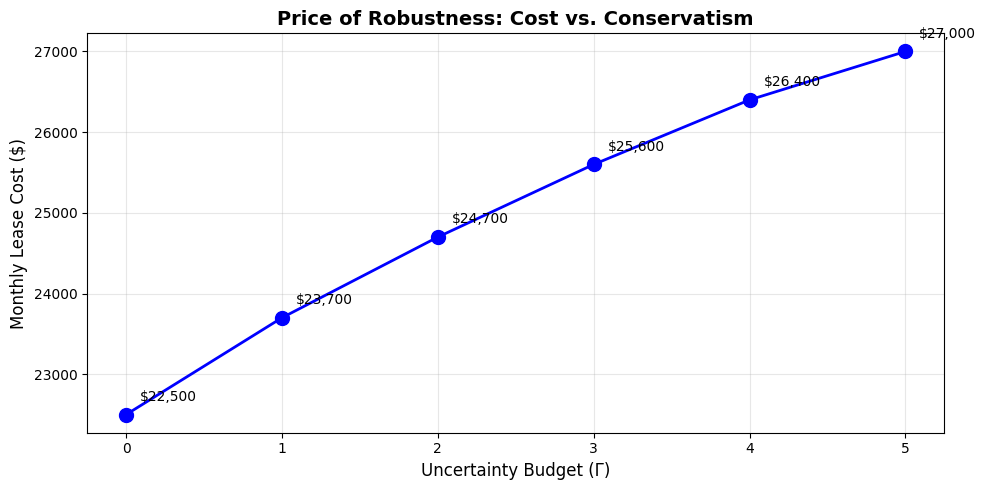

In [ ]:
# Visualize: Price of Robustness
fig, ax = plt.subplots(figsize=(10, 5))

gammas = [r[0] for r in robust_results]
r_costs = [r[2] for r in robust_results]
r_spaces = [r[1] for r in robust_results]

ax.plot(gammas, r_costs, 'bo-', linewidth=2, markersize=10)
for g, c in zip(gammas, r_costs):
    ax.annotate(f'${c:,.0f}', (g, c), textcoords='offset points',
                xytext=(10, 10), fontsize=10)

ax.set_xlabel('Uncertainty Budget (Γ)', fontsize=12)
ax.set_ylabel('Monthly Lease Cost ($)', fontsize=12)
ax.set_title('Price of Robustness: Cost vs. Conservatism', fontsize=14, fontweight='bold')
ax.set_xticks(gammas)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Stochastic Facility Location

### Problem

A company is deciding which of 3 warehouses to open (binary, first stage) to serve demand in 4 customer zones across 5 scenarios. This combines **integer programming** (facility selection) with **stochastic optimization** (uncertain demand).

In [ ]:
%%writefile stochastic_facility.mod
# Stochastic Facility Location
# First stage: binary facility opening decisions
# Second stage: allocation to serve stochastic demand

set WAREHOUSES;
set CUSTOMERS;
set SCENARIOS;

param prob{SCENARIOS} >= 0;
param fixed_cost{WAREHOUSES} >= 0;         # Opening cost
param capacity{WAREHOUSES} >= 0;           # Warehouse capacity
param demand{CUSTOMERS, SCENARIOS} >= 0;   # Demand per customer per scenario
param ship_cost{WAREHOUSES, CUSTOMERS} >= 0; # Shipping cost per unit
param penalty := 50;                        # Penalty for unmet demand

# First stage: open warehouse?
var open{WAREHOUSES} binary;

# Second stage: allocation and shortfall
var ship{WAREHOUSES, CUSTOMERS, SCENARIOS} >= 0;
var shortfall{CUSTOMERS, SCENARIOS} >= 0;

minimize total_cost:
    sum{w in WAREHOUSES} fixed_cost[w] * open[w]
    + sum{s in SCENARIOS} prob[s] * (
        sum{w in WAREHOUSES, c in CUSTOMERS} ship_cost[w,c] * ship[w,c,s]
        + sum{c in CUSTOMERS} penalty * shortfall[c,s]
    );

# Demand satisfaction (with shortfall)
subject to meet_demand{c in CUSTOMERS, s in SCENARIOS}:
    sum{w in WAREHOUSES} ship[w,c,s] + shortfall[c,s] >= demand[c,s];

# Capacity: can only ship from open warehouses
subject to cap{w in WAREHOUSES, s in SCENARIOS}:
    sum{c in CUSTOMERS} ship[w,c,s] <= capacity[w] * open[w];


Writing stochastic_facility.mod


In [ ]:
%%writefile stochastic_facility.dat
set WAREHOUSES := W1 W2 W3;
set CUSTOMERS := Zone1 Zone2 Zone3 Zone4;
set SCENARIOS := S1 S2 S3 S4 S5;

param prob :=
    S1 0.15  S2 0.25  S3 0.30  S4 0.20  S5 0.10;

param fixed_cost :=
    W1 10000  W2 8000  W3 12000;

param capacity :=
    W1 500  W2 400  W3 600;

param ship_cost:
        Zone1  Zone2  Zone3  Zone4 :=
W1        5      8     12     15
W2       10      4      7     11
W3       14     11      3      6;

param demand:
        S1    S2    S3    S4    S5 :=
Zone1  200   250   300   350   400
Zone2  150   200   250   300   350
Zone3  180   220   280   320   380
Zone4  120   160   200   250   300;

Overwriting stochastic_facility.dat


In [ ]:
# Solve stochastic facility location
facility_model = AMPL()
facility_model.option["solver"] = "gurobi"
facility_model.option["gurobi_options"] = "outlev=1"
facility_model.read("stochastic_facility.mod")
facility_model.readData("stochastic_facility.dat")
facility_model.solve()

print(f"\nSolve status: {facility_model.solve_result}")
print(f"Total expected cost: ${facility_model.obj['total_cost'].value():,.0f}")

# Display facility decisions
open_var = facility_model.var["open"]
warehouses = list(facility_model.set["WAREHOUSES"].members())
fc = facility_model.param["fixed_cost"]

print(f"\nFacility decisions (first stage):")
print(f"{'Warehouse':<12} {'Open?':>8} {'Fixed Cost':>12}")
print("-" * 35)
for w in warehouses:
    status = "YES" if open_var[w].value() > 0.5 else "no"
    print(f"{w:<12} {status:>8} ${fc[w]:>11,.0f}")

Gurobi 13.0.0: Set parameter LogToConsole to value 1
  tech:outlev = 1

AMPL MP initial flat model has 83 variables (0 integer, 3 binary);
Objectives: 1 linear; 
Constraints:  35 linear;

AMPL MP final model has 83 variables (0 integer, 3 binary);
Objectives: 1 linear; 
Constraints:  35 linear;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
InfUnbdInfo  1

Optimize a model with 35 rows, 83 columns and 155 nonzeros (Min)
Model fingerprint: 0xafd0f47d
Model has 83 linear objective coefficients
Variable types: 80 continuous, 3 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+02]
  Objective range  [3e-01, 1e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+02, 4e+02]
Found heuristic solution: objective 5005

In [ ]:
# Show allocation for each scenario
ship_var = facility_model.var["ship"]
shortfall_var = facility_model.var["shortfall"]
customers = list(facility_model.set["CUSTOMERS"].members())
scenarios_fl = list(facility_model.set["SCENARIOS"].members())
demand_fl = facility_model.param["demand"]

for s in scenarios_fl:
    print(f"\n--- Scenario {s} ---")
    print(f"{'Customer':<10}", end="")
    for w in warehouses:
        if open_var[w].value() > 0.5:
            print(f" {w:>8}", end="")
    print(f" {'Shortfall':>10} {'Demand':>8}")
    print("-" * 55)
    for c in customers:
        print(f"{c:<10}", end="")
        for w in warehouses:
            if open_var[w].value() > 0.5:
                print(f" {ship_var[w, c, s].value():>8.0f}", end="")
        sf = shortfall_var[c, s].value()
        print(f" {sf:>10.0f} {demand_fl[c, s]:>8.0f}")


--- Scenario S1 ---
Customer         W1       W3  Shortfall   Demand
-------------------------------------------------------
Zone1           200        0          0      200
Zone2           150        0          0      150
Zone3             0      180          0      180
Zone4             0      120          0      120

--- Scenario S2 ---
Customer         W1       W3  Shortfall   Demand
-------------------------------------------------------
Zone1           250        0          0      250
Zone2           200        0          0      200
Zone3             0      220          0      220
Zone4             0      160          0      160

--- Scenario S3 ---
Customer         W1       W3  Shortfall   Demand
-------------------------------------------------------
Zone1           300        0          0      300
Zone2           200       50          0      250
Zone3             0      280          0      280
Zone4             0      200          0      200

--- Scenario S4 ---
Customer     

---
## 6. Student Exercises

### Exercise 1: Flu Vaccine Ordering

A regional clinic must order flu vaccines in September at \$12/dose. Unused doses expire. Emergency doses cost \$28. Revenue per administered dose is \$20.

| Scenario | Doses needed | Probability |
|----------|-------------|-------------|
| Mild     | 5,000       | 0.4         |
| Moderate | 8,000       | 0.4         |
| Severe   | 12,000      | 0.2         |

Formulate, solve, and compute VSS and EVPI.

In [ ]:
# TODO: Formulate and solve the flu vaccine stochastic LP
# Hint: Follow the same pattern as the brewery model
# 1. Write a .mod file with first-stage (order quantity) and second-stage (administer, emergency, waste)
# 2. Write a .dat file with scenarios
# 3. Solve and compute RP, EEV, WS, VSS, EVPI

# Your code here:


### Exercise 2: Sensitivity to Scenario Probabilities

Using the brewery model, investigate how the optimal grain purchase changes as you vary the probability of the High-demand scenario from 0.05 to 0.40 (adjusting Low and Medium proportionally). Plot the optimal grain purchase vs. High-scenario probability.

In [ ]:
# TODO: Parametric analysis of probability sensitivity
# Loop over p_high values, solve each, and plot

# Your code here:


### Exercise 3: Robust vs. Stochastic Comparison

For the warehouse leasing problem, compare the 90% chance-constrained solution to the robust solution with Gamma=3. Which leases more space? Which is more conservative, and why? Evaluate both solutions against 1,000 randomly generated donation scenarios and report what fraction of scenarios each solution covers.

In [ ]:
# TODO: Simulate 1000 scenarios and evaluate both solutions
# Hint: Use np.random to generate donation volumes, then check
#       what fraction each solution covers

# Your code here:
